# Opus-MT (Zero-Shot)

**Model   :** `opus-mt-en-ar`  



---
## Step 1 — Install Packages

In [17]:
!pip install -q transformers sentencepiece sacrebleu bert-score


In [18]:
import os, time, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import MarianMTModel, MarianTokenizer
from sacrebleu.metrics import BLEU
from bert_score import score as bert_score

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'



## Step 2 — data loading



In [19]:
from google.colab import files

uploaded = files.upload()

for fname, data in uploaded.items():
    print(f'  {fname}  ({len(data):,} bytes)')

Saving ascat_val.csv to ascat_val (2).csv
Saving ascat_train_balanced.csv to ascat_train_balanced (2).csv
Saving ascat_train.csv to ascat_train (2).csv
Saving ascat_test.csv to ascat_test (2).csv
Saving ascat_cleaned.csv to ascat_cleaned (2).csv
  ascat_val (2).csv  (339,312 bytes)
  ascat_train_balanced (2).csv  (5,913,372 bytes)
  ascat_train (2).csv  (1,526,265 bytes)
  ascat_test (2).csv  (335,686 bytes)
  ascat_cleaned (2).csv  (2,201,077 bytes)


---
## Step 3 — Load & Preview Data

In [20]:

SRC_COL = 'en_clean'
REF_COL = 'ar_clean'

#
BATCH_SIZE = 16
MAX_LEN    = 512

# Output folder (inside Colab session)
OUTPUT_DIR = '/content/opus_mt_output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def load_csv(filename):
    """Load a CSV and keep only the two columns we need."""
    df = pd.read_csv(filename)[[SRC_COL, REF_COL]].dropna().reset_index(drop=True)
    print(f'  {filename:22s}  →  {len(df):>4} rows')
    return df

print('Loading...')
train_df = load_csv('ascat_train.csv')
val_df   = load_csv('ascat_val.csv')
test_df  = load_csv('ascat_test.csv')

print('\nSample from test set:')
test_df[[SRC_COL, REF_COL]].head(2)

  ascat_train.csv         →   373 rows
  ascat_val.csv           →    80 rows
  ascat_test.csv          →    80 rows


,en_clean,ar_clean
0,There is currently a great deal of interest in...,هناك اهتمام كبير حاليا بالامكانيه النظريه والع...
1,We present a renormalization group motivation ...,نقدم دافعا لمجموعه اعاده التطبيع لتسلسلات المق...


---
## Step 4 — Load Model & Translate

In [21]:
MODEL_NAME = 'Helsinki-NLP/opus-mt-en-ar'
print(f'Downloading {MODEL_NAME} ...')
tokenizer = MarianTokenizer.from_pretrained(MODEL_NAME)
model     = MarianMTModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print(' Model ready')

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(62802, 512, padding_idx=62801)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(62802, 512, padding_idx=62801)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [22]:
def translate(texts):
    """Translate a list of English strings → Arabic."""
    results       = []
    total_batches = (len(texts) + BATCH_SIZE - 1) // BATCH_SIZE

    for i in range(0, len(texts), BATCH_SIZE):
        batch = texts[i : i + BATCH_SIZE]

        enc = tokenizer(
            batch,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=MAX_LEN
        ).to(DEVICE)

        with torch.no_grad():
            out = model.generate(**enc, num_beams=4)

        results.extend(tokenizer.batch_decode(out, skip_special_tokens=True))

        batch_num = i // BATCH_SIZE + 1
        if batch_num % 10 == 0 or batch_num == total_batches:
            print(f'  batch {batch_num}/{total_batches}', flush=True)

    return results

In [27]:
splits = {'train': train_df, 'val': val_df, 'test': test_df}

for name, df in splits.items():
    print(f'\nTranslating {name} ({len(df)} sentences)...')
    t0 = time.time()
    df['hypothesis'] = translate(df[SRC_COL].tolist())
    elapsed = time.time() - t0



Translating train (373 sentences)...
  batch 10/24
  batch 20/24
  batch 24/24

Translating val (80 sentences)...
  batch 5/5

Translating test (80 sentences)...
  batch 5/5


---
## Step 5 — Compute BLEU & BERTScore

In [28]:
bleu_metric = BLEU()
def evaluate(df, name):
    hyps = df['hypothesis'].tolist()
    refs = df[REF_COL].tolist()

    # BLEU  (0–100)
    bleu = bleu_metric.corpus_score(hyps, [refs]).score

    # BERTScore  (0–1)  —  lang='ar' uses Arabic multilingual BERT
    P, R, F1 = bert_score(hyps, refs, lang='ar', device=DEVICE,
                           verbose=False, batch_size=64)
    row = {
        'split'        : name,
        'sentences'    : len(df),
        'BLEU'         : round(bleu,             4),
        'BERTScore_P'  : round(P.mean().item(),   4),
        'BERTScore_R'  : round(R.mean().item(),   4),
        'BERTScore_F1' : round(F1.mean().item(),  4),
    }
    print(f"  {name:5s} | BLEU {row['BLEU']:6.2f} | BERTScore F1 {row['BERTScore_F1']:.4f}")
    return row

print('Computing metrics...\n')
rows = [evaluate(df, name) for name, df in splits.items()]
metrics_df = pd.DataFrame(rows)

print('\nFull summary:')
metrics_df

Computing metrics...



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  train | BLEU   7.50 | BERTScore F1 0.7680


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

  val   | BLEU   7.91 | BERTScore F1 0.7646


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  test  | BLEU   7.32 | BERTScore F1 0.7782

Full summary:


,split,sentences,BLEU,BERTScore_P,BERTScore_R,BERTScore_F1
0,train,373,7.5043,0.7754,0.7621,0.7680
1,val,80,7.9144,0.7793,0.7521,0.7646
2,test,80,7.3182,0.7894,0.7688,0.7782


---
## Step 6 — Charts

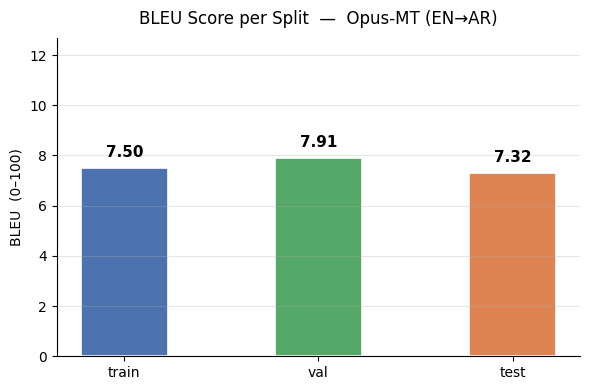

In [29]:
COLORS      = ['#4C72B0', '#55A868', '#DD8452']
split_names = metrics_df['split'].tolist()

# ── Chart 1: BLEU per split ────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(split_names, metrics_df['BLEU'],
              color=COLORS, width=0.45, edgecolor='white', linewidth=1.2)

for bar, val in zip(bars, metrics_df['BLEU']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('BLEU Score per Split  —  Opus-MT (EN→AR)', fontsize=12, pad=10)
ax.set_ylabel('BLEU  (0–100)')
ax.set_ylim(0, max(metrics_df['BLEU']) * 1.35 + 2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'chart_bleu.png', dpi=150)
plt.show()


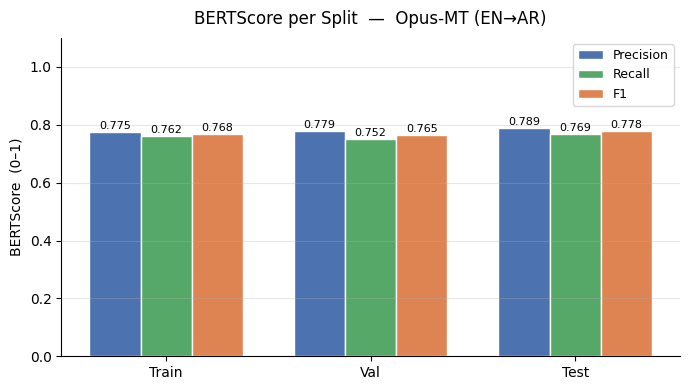

In [30]:
# ── Chart 2: BERTScore P / R / F1 ─────────────────────────
x, w = np.arange(len(split_names)), 0.25

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w, metrics_df['BERTScore_P'],  w, label='Precision', color='#4C72B0', edgecolor='white')
b2 = ax.bar(x,     metrics_df['BERTScore_R'],  w, label='Recall',    color='#55A868', edgecolor='white')
b3 = ax.bar(x + w, metrics_df['BERTScore_F1'], w, label='F1',        color='#DD8452', edgecolor='white')

for group in [b1, b2, b3]:
    for bar in group:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in split_names])
ax.set_title('BERTScore per Split  —  Opus-MT (EN→AR)', fontsize=12, pad=10)
ax.set_ylabel('BERTScore  (0–1)')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'chart_bertscore.png', dpi=150)
plt.show()


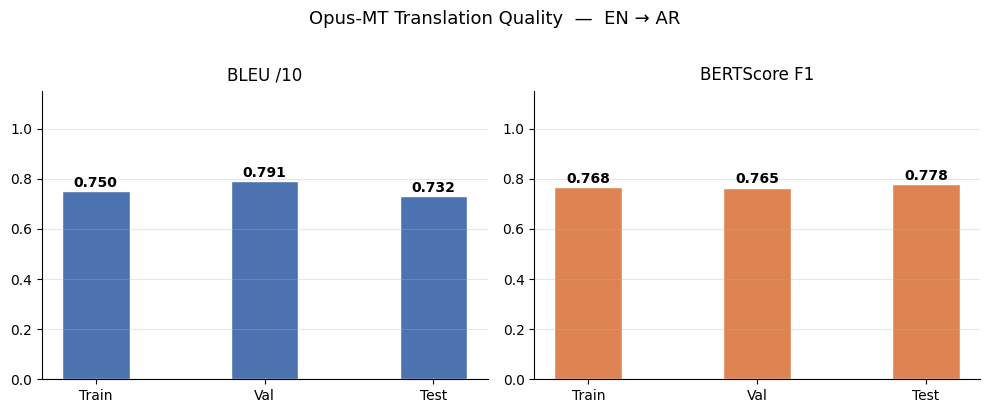

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for ax, values, title, colour in [
    (ax1, metrics_df['BLEU'] /10,   'BLEU /10', '#4C72B0'),
    (ax2, metrics_df['BERTScore_F1'], 'BERTScore F1',          '#DD8452'),
]:
    bars = ax.bar(split_names, values, color=colour, width=0.4, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_ylim(0, 1.15)
    ax.set_xticklabels([s.capitalize() for s in split_names])
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Opus-MT Translation Quality  —  EN → AR', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'chart_combined.png', dpi=150, bbox_inches='tight')
plt.show()


---
##Sample Translations (Test Set)

In [40]:
print('=' * 65)
for _, row in test_df.head(3).iterrows():
    print(f'EN  : {str(row[SRC_COL])[:110]}...')
    print(f'REF : {str(row[REF_COL])[:110]}...')
    print(f'HYP : {str(row["hypothesis"])[:110]}...')
    print('-' * 65)

EN  : There is currently a great deal of interest in the theoretical and practical possibility of cloaking objects f...
REF : هناك اهتمام كبير حاليا بالامكانيه النظريه والعمليه لحجب الاجسام عن طريق الموجات الكهرومغناطيسيه. الفكره الاساس...
HYP : يوجد في الوقت الراهن قدر كبير من الاهتمام في الإمكانية النظرية والعملية لإخفاء الأجسام من الملاحظة بالموجات ال...
-----------------------------------------------------------------
EN  : We present a renormalization group motivation of scale hierarchies in SUSY SU(5) model. The Split Higgsino sca...
REF : نقدم دافعا لمجموعه اعاده التطبيع لتسلسلات المقاييس الهرميه في نموذج SUSY SU(5). يتم النظر في سيناريو تقسيم اله...
HYP : نحن نعرض حافز مجموعة إعادة التطبيع للتسلسل الهرمي للحجم في نموذج SUSY SU(5). يُنظر بالتفصيل في مسح التضاريس Hi...
-----------------------------------------------------------------
EN  : We propose and analyze a new method to produce single and entangled photons which does not require cavities. I...
REF : نقترح ونحلل طريقه جديد